# PaySim EDA — 200K Temporal Subsample

Exploratory analysis of `data/processed/paysim_200k.parquet` — the first 200,000 transactions of the PaySim dataset in temporal order (steps 1–13).

**Goals of this notebook:**
1. Understand the shape and types of the data
2. Quantify class imbalance (fraud is rare — *how* rare?)
3. See which transaction types actually contain fraud
4. Compare amount distributions for fraud vs. non-fraud
5. Look at temporal patterns via the `step` column

Output of this notebook informs feature engineering choices in Milestone 2.5 and graph design in Phase 6.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Repo root: notebook lives at <repo>/notebooks/01_paysim_eda.ipynb
REPO_ROOT = Path.cwd().parent
PARQUET = REPO_ROOT / "data" / "processed" / "paysim_200k.parquet"

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

df = pd.read_parquet(PARQUET)
print(f"Loaded {len(df):,} rows from {PARQUET.name}")
df.head()

Loaded 200,000 rows from paysim_200k.parquet


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 1. Shape, dtypes, missing values

In [2]:
print(f"Shape: {df.shape}")
print(f"\nDtypes:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isna().sum())
print(f"\nTotal missing: {df.isna().sum().sum()}")

Shape: (200000, 11)

Dtypes:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Total missing: 0


## 2. Class imbalance

`isFraud` is the binary target. `isFlaggedFraud` is PaySim's *naive* rule-based flag (mostly useless — it triggers on a hardcoded threshold). The real target is `isFraud`.

In [3]:
fraud_counts = df["isFraud"].value_counts()
fraud_pct = df["isFraud"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": fraud_counts, "percent": fraud_pct.round(4)})
summary.index = ["legitimate (0)", "fraud (1)"]
print(summary)

print(f"\nClass imbalance ratio (legit : fraud) = {fraud_counts[0] / fraud_counts[1]:.0f} : 1")
print(f"\nisFlaggedFraud catches: {df['isFlaggedFraud'].sum()} / {df['isFraud'].sum()} actual fraud rows")

                 count  percent
legitimate (0)  199853  99.9265
fraud (1)          147   0.0735

Class imbalance ratio (legit : fraud) = 1360 : 1

isFlaggedFraud catches: 0 / 147 actual fraud rows


## 3. Transaction type breakdown

type
PAYMENT     73427
CASH_OUT    66488
CASH_IN     41579
TRANSFER    16836
DEBIT        1670
Name: count, dtype: int64


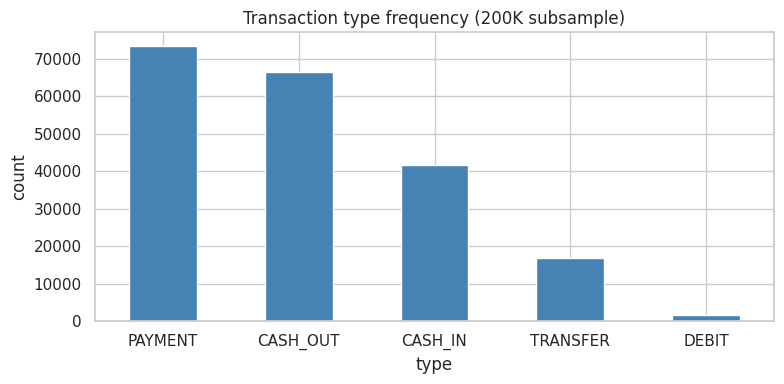

In [4]:
type_counts = df["type"].value_counts()
print(type_counts)

fig, ax = plt.subplots(figsize=(8, 4))
type_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Transaction type frequency (200K subsample)")
ax.set_ylabel("count")
ax.set_xlabel("type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Where does fraud live?

Critical insight: in PaySim, fraud only occurs in two transaction types. This means any non-`TRANSFER`/`CASH_OUT` transaction is provably legitimate — useful prior for the graph model.

In [5]:
fraud_by_type = df.groupby("type")["isFraud"].agg(["sum", "count"])
fraud_by_type["fraud_rate_%"] = (fraud_by_type["sum"] / fraud_by_type["count"] * 100).round(4)
fraud_by_type = fraud_by_type.rename(columns={"sum": "fraud_count", "count": "total"})
print(fraud_by_type.sort_values("fraud_count", ascending=False))

          fraud_count  total  fraud_rate_%
type                                      
CASH_OUT           75  66488        0.1128
TRANSFER           72  16836        0.4277
CASH_IN             0  41579        0.0000
DEBIT               0   1670        0.0000
PAYMENT             0  73427        0.0000


## 5. Amount distribution: fraud vs legitimate

Amounts are heavy-tailed. Plot on log scale so the fraud distribution doesn't get crushed by legitimate-side outliers.

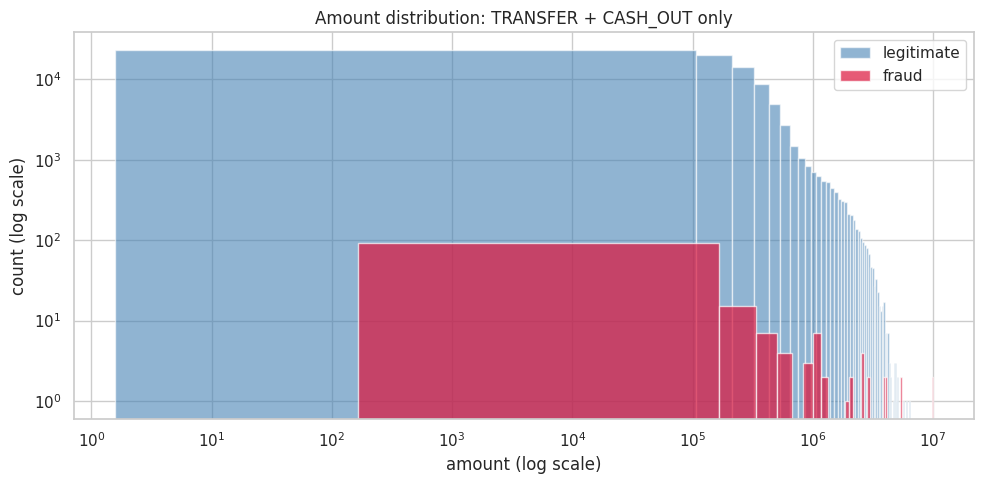

Fraud amount stats:
count         147.00
mean       635893.20
std       1522141.80
min           164.00
25%         13707.11
50%         43092.00
75%        361559.69
max      10000000.00
Name: amount, dtype: float64


In [6]:
# Filter to types where fraud actually occurs
fraud_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(
    fraud_types[fraud_types["isFraud"] == 0]["amount"],
    bins=60,
    alpha=0.6,
    label="legitimate",
    color="steelblue",
    log=True,
)
ax.hist(
    fraud_types[fraud_types["isFraud"] == 1]["amount"],
    bins=60,
    alpha=0.7,
    label="fraud",
    color="crimson",
    log=True,
)
ax.set_xscale("log")
ax.set_xlabel("amount (log scale)")
ax.set_ylabel("count (log scale)")
ax.set_title("Amount distribution: TRANSFER + CASH_OUT only")
ax.legend()
plt.tight_layout()
plt.show()

print("Fraud amount stats:")
print(fraud_types[fraud_types["isFraud"] == 1]["amount"].describe().round(2))

## 6. Temporal pattern via `step`

`step` is hour-offset from t=0. Since our subsample covers steps 1–13, this is the first ~13 hours of the simulation. Group fraud count by step to see if there's any temporal clustering.

      sum  count  fraud_rate_%
step                          
1      16   2708        0.5908
2       8   1014        0.7890
3       4    552        0.7246
4      10    565        1.7699
5       6    665        0.9023
6      22   1660        1.3253
7      12   6837        0.1755
8      12  21097        0.0569
9      19  37628        0.0505
10     11  35991        0.0306
11      7  37241        0.0188
12     14  36153        0.0387
13      6  17889        0.0335


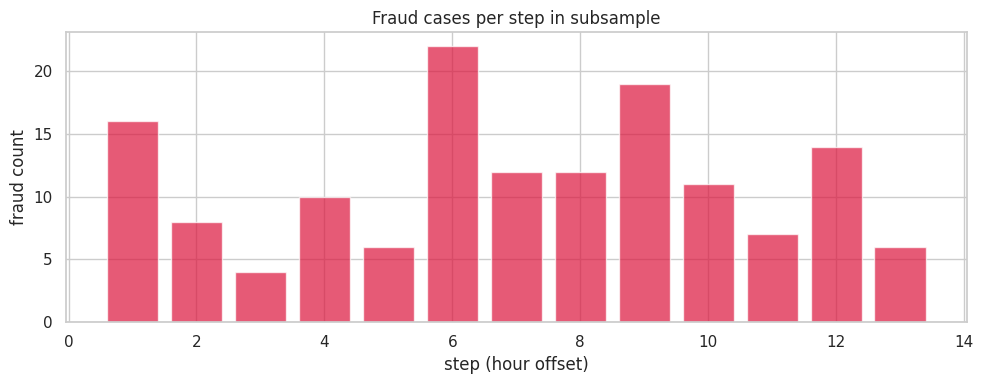

In [7]:
fraud_per_step = df.groupby("step")["isFraud"].agg(["sum", "count"])
fraud_per_step["fraud_rate_%"] = (fraud_per_step["sum"] / fraud_per_step["count"] * 100).round(4)
print(fraud_per_step)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(fraud_per_step.index, fraud_per_step["sum"], color="crimson", alpha=0.7)
ax.set_xlabel("step (hour offset)")
ax.set_ylabel("fraud count")
ax.set_title("Fraud cases per step in subsample")
plt.tight_layout()
plt.show()

## Key takeaways

- **200,000 rows, 11 columns, zero missing values.** Clean dataset.
- **Severe class imbalance**: ~1360:1 (147 fraud rows in 200K). This dictates: use **PR-AUC** as the primary metric (not accuracy), apply **class-weighted loss** or **SMOTE** for training, and never trust naive accuracy.
- **Fraud lives only in `TRANSFER` and `CASH_OUT`.** Other transaction types (PAYMENT, CASH_IN, DEBIT) have zero fraud in this subsample. Useful as a hard prior for the graph model.
- **`isFlaggedFraud` is near-useless** — it catches a tiny fraction of actual fraud. Confirms the need for a learned model.
- **Fraud amounts skew higher than legitimate** in the TRANSFER/CASH_OUT subset (heavy-tail; visible on log-log plot).
- **Subsample spans steps 1–13** (~13 hours). Phase 2.6 will need a temporal split inside this window.

Next steps: Milestone 2.5 (feature engineering — log-transformed amounts, hour-of-day derivation, binary type flags).